In [5]:
"""
棋盘设置:15*15
黑棋的位置(-1)，白棋的位置(1)，身份标识，全局视野。

简单深度学习全流程训练：
    / 目标实现：
        1.128个文件逐个读取，进行122局同步解析完成数据准备
        2.搭建dataloader数据加载器，实现多进程加速
        3.完成简单的策略网络的深度学习训练
        4.可视化技术
"""

# 导入必要的包
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import TensorDataset,DataLoader,random_split
import numpy as np
import src.game_assist as game_assist
from src.net import trick_net
import matplotlib.pyplot as plt
import os

In [6]:
########################################
# 1.数据准备
    # 由于量不多，可以直接全部读入内存
    # 打开所有文件 
game_state = game_assist.GomokuGame(122)
all_train_data = []
all_train_labels = []
all_files_number = 184
for index in range(all_files_number):
    path = f"data\\processed\\proData_{index + 1}.txt"
    file_lines = []

    # 读取文件内容并转化为张量储存[180,122] 
    try:
        with open(path, 'r', encoding='utf-8') as file:
            # 读取所有行
            data = np.loadtxt(path, dtype=np.float32) 
            # 验证形状
            if data.shape[1] != 180:
                print(f"错误，期望列数180，实际{data.shape[1]}")
            # 转换为PyTorch张量
            tensor = torch.from_numpy(data).to(torch.float32)
            tensor = tensor.T
            # print(f"形状: {tensor.shape}")
    except Exception as e:
        print(f"处理文件 {path} 时出错: {e}")
        continue
    
    # 122局同步解析
    # 创建棋盘
    game_state.reset()
    all_train_data.append(game_state.trainMap.clone()) #第一步是空棋盘
    for move_index in range(180):
        move = tensor[move_index]
        valid = game_state.makeMove(move)
        if not valid:
            print(f"错误，文件 {path} 中第 {move_index} 步无效")
            continue
        # 记录数据
        board_state = game_state.trainMap.clone()
        all_train_data.append(board_state)
        all_train_labels.append(move)
    all_train_data.pop() #最后一个状态没有对应的标签

    ''''''
    print(f"数据导入进度：{100*(index+1)/all_files_number}%")
    ''''''
    '''
    # 检查有无正确储存数据
    print(all_train_data[index].shape)
    print(all_train_labels[index].shape)
    game_state.viewBoard()
    '''

'''
现在：
all_train_data 储存着tensor[122,4,15,15]张量
all_train_labels 储存着tensor[122]张量
'''
#连接所有张量
all_train_data   = torch.cat(all_train_data,dim=0)
all_train_labels = torch.cat(all_train_labels,dim=0)  

#清除其中无效数据
mask = all_train_labels >= 0
all_train_data = all_train_data[mask]
all_train_labels = all_train_labels[mask]

''''''
print("所有样本导入完毕,大小为:",all_train_data.shape)
print("所有标签导入完毕,大小为:",all_train_labels.shape)
''''''


数据导入进度：0.5434782608695652%
数据导入进度：1.0869565217391304%
数据导入进度：1.6304347826086956%
数据导入进度：2.1739130434782608%
数据导入进度：2.717391304347826%
数据导入进度：3.260869565217391%
数据导入进度：3.8043478260869565%
数据导入进度：4.3478260869565215%
数据导入进度：4.891304347826087%
数据导入进度：5.434782608695652%
数据导入进度：5.978260869565218%
数据导入进度：6.521739130434782%
数据导入进度：7.065217391304348%
数据导入进度：7.608695652173913%
数据导入进度：8.152173913043478%
数据导入进度：8.695652173913043%
数据导入进度：9.23913043478261%
数据导入进度：9.782608695652174%
数据导入进度：10.326086956521738%
数据导入进度：10.869565217391305%
数据导入进度：11.41304347826087%
数据导入进度：11.956521739130435%
数据导入进度：12.5%
数据导入进度：13.043478260869565%
数据导入进度：13.58695652173913%
数据导入进度：14.130434782608695%
数据导入进度：14.673913043478262%
数据导入进度：15.217391304347826%
数据导入进度：15.76086956521739%
数据导入进度：16.304347826086957%
数据导入进度：16.847826086956523%
数据导入进度：17.391304347826086%
数据导入进度：17.934782608695652%
数据导入进度：18.47826086956522%
数据导入进度：19.02173913043478%
数据导入进度：19.565217391304348%
数据导入进度：20.108695652173914%
数据导入进度：20.652173913043477%
数据导入进度

''

In [7]:
########################################
# 2.dataloader搭建
all_train_labels = all_train_labels.long() 
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
mp.set_start_method('spawn', force=True)
mp.freeze_support()

dataset = TensorDataset(all_train_data, all_train_labels)
train_size = int(0.8 * len(dataset)) 
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 1024
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=False,
    drop_last=False,
    multiprocessing_context='spawn' 
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,  
    num_workers=4,
    pin_memory=False,
    drop_last=False,
    multiprocessing_context='spawn' 
)

模型加载成功
Epoch 001/100: Train Loss: 1.7568 | Train Acc:  50.24% | Val Loss: 1.8751 | Val Acc:  48.55% | LR: 0.008751


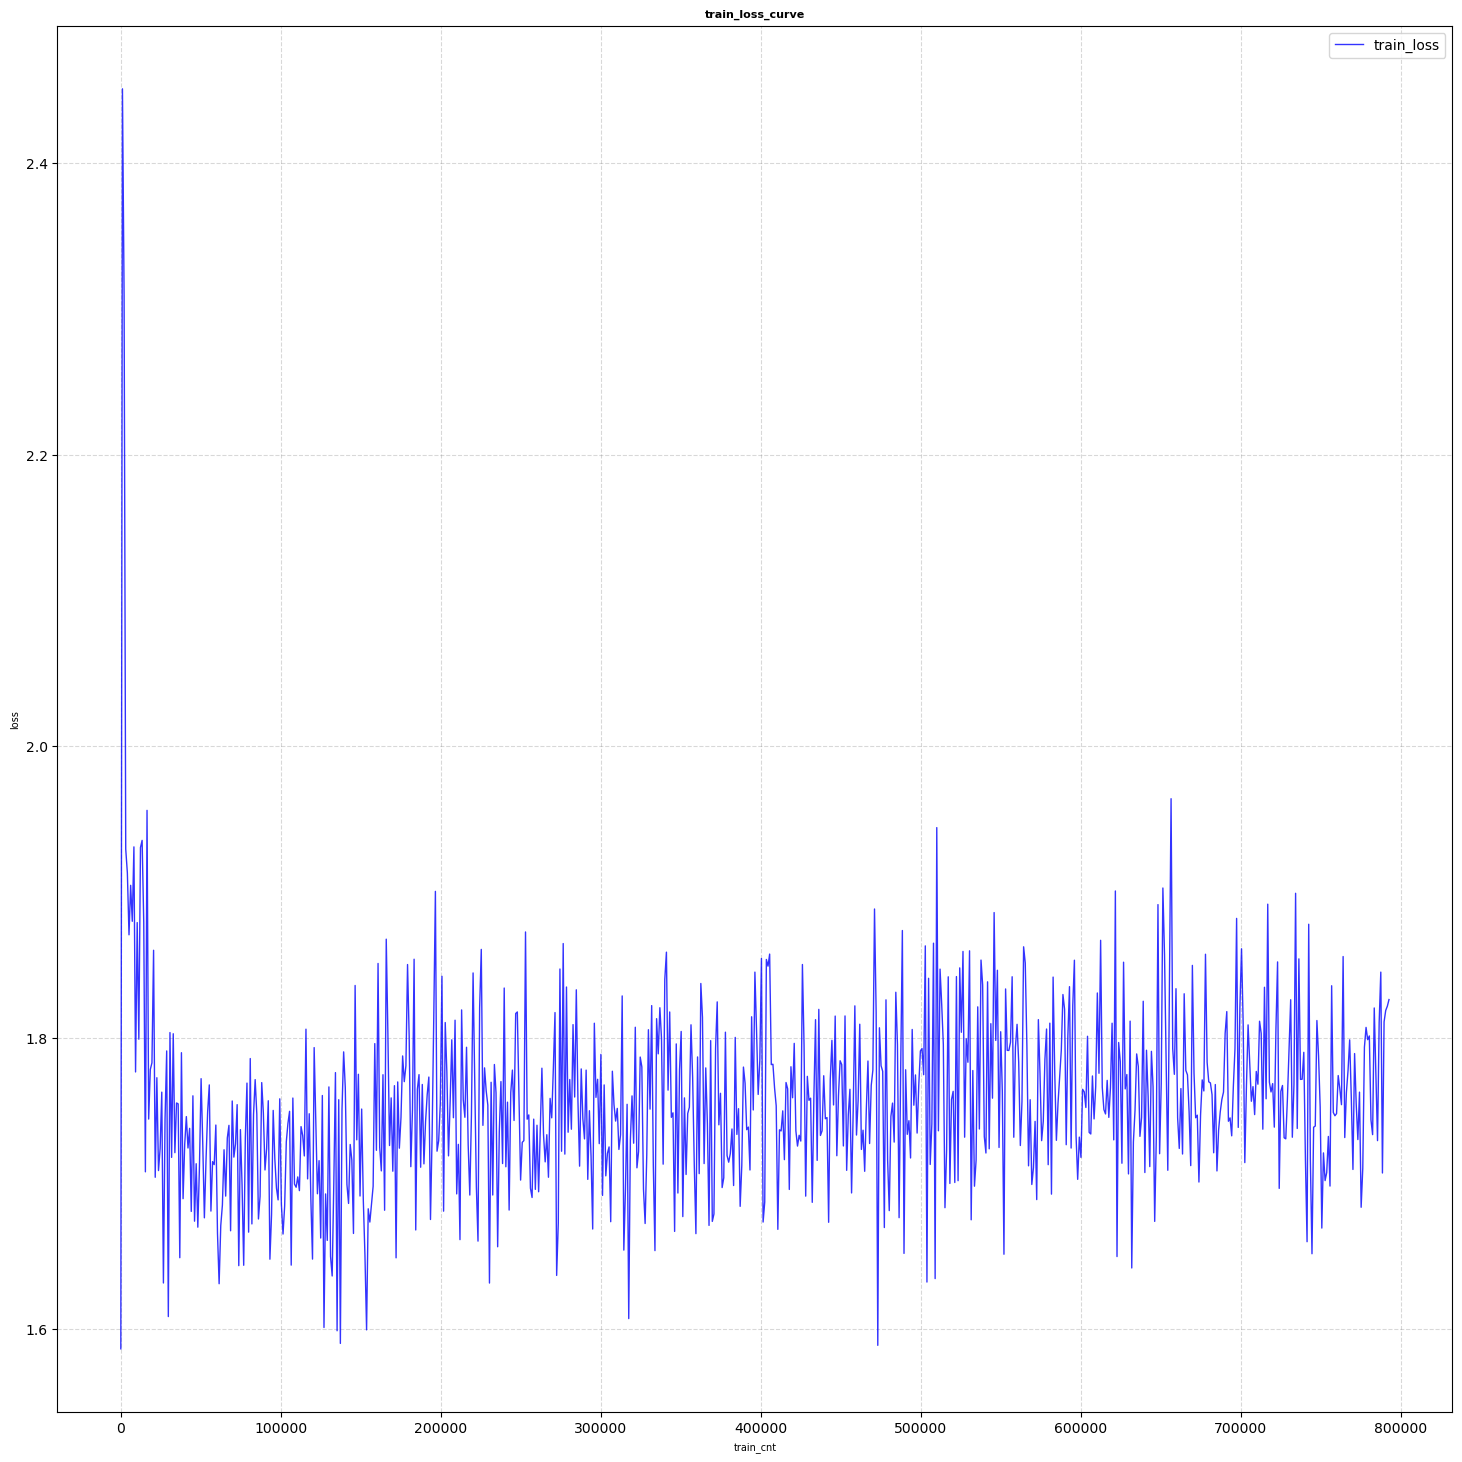

Epoch 002/100: Train Loss: 1.7350 | Train Acc:  50.71% | Val Loss: 1.8785 | Val Acc:  48.37% | LR: 0.007500


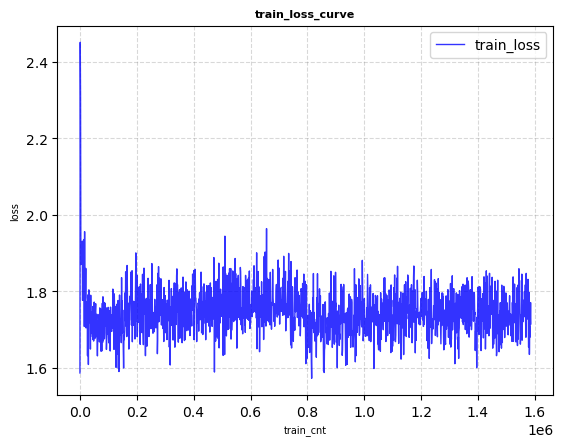

Epoch 003/100: Train Loss: 1.7116 | Train Acc:  51.13% | Val Loss: 1.8673 | Val Acc:  48.84% | LR: 0.006250


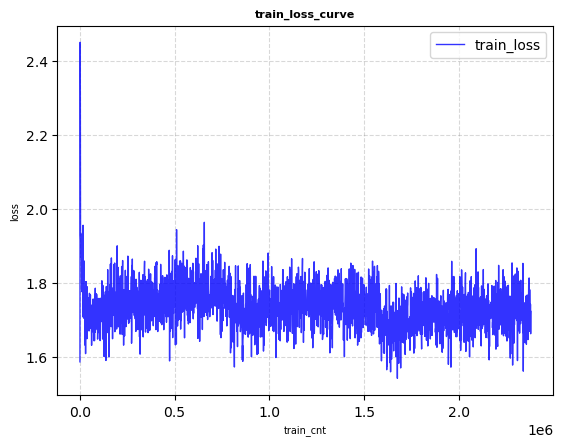

Epoch 004/100: Train Loss: 1.6863 | Train Acc:  51.75% | Val Loss: 1.8607 | Val Acc:  48.83% | LR: 0.004999


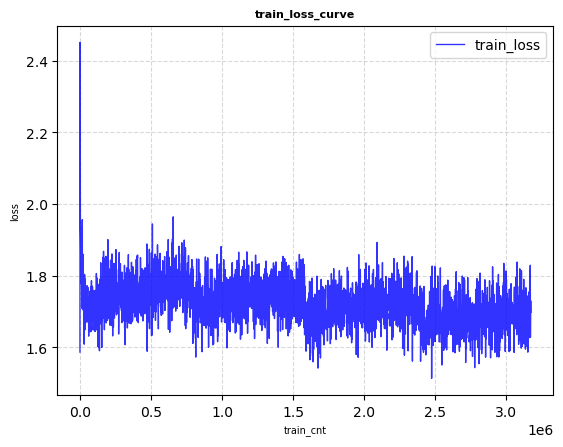

Epoch 005/100: Train Loss: 1.6581 | Train Acc:  52.31% | Val Loss: 1.8320 | Val Acc:  49.39% | LR: 0.003748


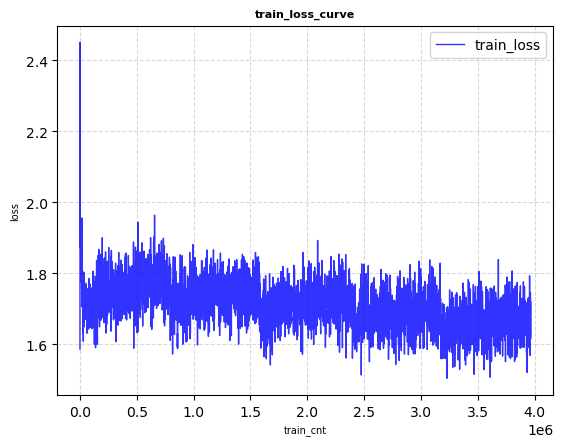

Epoch 006/100: Train Loss: 1.6303 | Train Acc:  52.95% | Val Loss: 1.8311 | Val Acc:  49.52% | LR: 0.002497


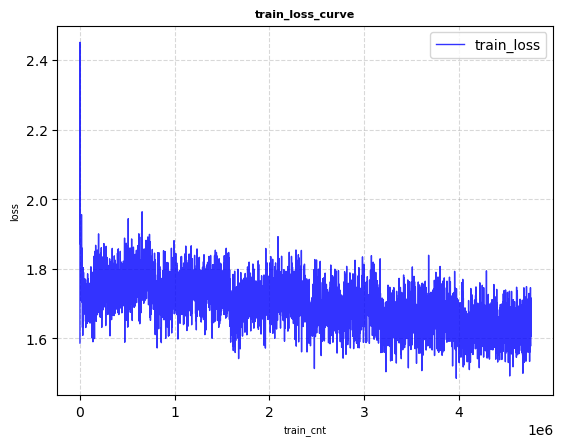

KeyboardInterrupt: 

In [12]:
x_plot = []
y_plot = []
all_steps = 0
plt.figure(figsize=(18, 18), dpi=100, facecolor='white')
plt.ion()

# 损失曲线图绘制
def draw():
    plt.clf()
    plt.plot(x_plot, y_plot, 'b-', linewidth=1, label='train_loss', alpha=0.8)
    plt.title('train_loss_curve', fontsize=8, fontweight='bold')
    plt.xlabel('train_cnt', fontsize=7)
    plt.ylabel('loss', fontsize=7)
    plt.grid(True, alpha=0.3, linestyle='--', color='gray')
    plt.legend()
    plt.show(block=False)
    plt.pause(0.1)

########################################
# 3.深度学习训练

# 初始化参数
initial_lr = 1e-2
num_epochs = 100
device = torch.device("cpu")

cnn = trick_net().to(device)
try:
    state_dict = torch.load(f"model//trick.pkl",map_location=torch.device(device))
    if isinstance(state_dict, nn.Module):
        cnn = state_dict
    else:
        cnn.load_state_dict(state_dict)
    print("模型加载成功")
except:
    print("没有训练好的模型，从0开始训练")

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), initial_lr)

with open("log.txt","a") as log_file:
    for epoch in range(num_epochs):
        cnn.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)    
            
            outputs = cnn(batch_features)
            loss = loss_func(outputs, batch_labels)

            optimizer.zero_grad()
            loss.backward()
                
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += batch_labels.size(0)
            train_correct += (predicted == batch_labels).sum().item()
            
            # 简单poly下降
            lr = max(initial_lr * (1 - all_steps / int(991446*num_epochs*0.8*0.08)),1e-8)  
                    # 总步数*自定义参量
            for param_group in optimizer.param_groups:
                param_group['lr'] = max(lr,1e-6)
            optimizer.step()
            # 修改plot数据表
            x_plot.append(all_steps)
            all_steps += batch_size
            y_plot.append(loss.item())

        cnn.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features = batch_features.to(device)
                batch_labels = batch_labels.to(device)
                
                outputs = cnn(batch_features)
                loss = loss_func(outputs, batch_labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += batch_labels.size(0)
                val_correct += (predicted == batch_labels).sum().item()
            
            # 打印统计信息
            train_acc = 100 * train_correct / train_total
            val_acc = 100 * val_correct / val_total
            
            log_line = (f'Epoch {epoch+1:03d}/{num_epochs}: '
                        f'Train Loss: {train_loss/len(train_loader):.4f} | '
                        f'Train Acc: {train_acc:6.2f}% | '
                        f'Val Loss: {val_loss/len(val_loader):.4f} | '
                        f'Val Acc: {val_acc:6.2f}% | '
                        f'LR: {lr:.6f}\n')
            log_file.write(log_line)
            print(log_line,end='')
        # 每一个epoch更新一次模型
        torch.save(cnn.state_dict(), f"model//trick.pkl")
        # 可视化技术
        draw()

# 最终保存
plt.ioff()
plt.show()
log_file.close()
print("训练完毕！")
torch.save(cnn.state_dict(), "model/game_next_model_final.pkl")
